In [72]:
#!/usr/bin/env python3

import numpy as np
import sys
import json 
from scipy.optimize import minimize, brentq
from matplotlib import pyplot as plt
import matplotlib as mpl
import yaml
import mplhep as hep
hep.style.use("ATLAS")

sys.path.append('../Recast/CMS-TOP-20-001_mtt')

from cms_top_20_001_Limits import read_CMSdata, getSMLO, getKfactor, cms_bins, bin_widths, getUL, chi2

brFactor = 2*0.67*0.2147 # Semi-leptonic branching ratio to be applied to the ttbar (undecayed) signal

## Compute Limits on yDM

In [73]:
def computeULs(signal_xsec,bg_xsec,obs_xsec,covMatrix,full=False,cl=0.95,kfac=1.0):

    # Rescale predictions by bin-dependent k-factors
    signal = kfac*signal_xsec[:]
    xsecsObs = obs_xsec[:]
    sm = bg_xsec[:]

    result = {'obs' : {}, 'exp' : {}}
    
    if not full: # Use simplified chi-square
        # Finally, divide by the bin widths
        signal = signal/bin_widths
        sm_bin = sm/bin_widths
        resDict = getUL(signal,sm_bin,xsecsObs,covMatrix,deltas=0.0,cl=cl)
        result['obs'].update(resDict)
        # Expected
        resDictExp = getUL(signal,sm_bin,sm_bin,covMatrix,deltas=0.0,cl=cl)
        result['exp'].update(resDictExp)
       
        
    else: # Use full CLs calculation
        import sys
        sys.path.append('../Recast/statisticalTools')
        from simplifiedLikelihoods import Data,UpperLimitComputer,LikelihoodComputer
        ulComp = UpperLimitComputer(cl=cl)

        # ### Get number of observed and expected (BG) events
        lumi = 137*1e3
        nobs = xsecsObs*bin_widths*lumi
        nbg = sm*lumi
        ns = signal*lumi
        cov = covMatrix*(lumi*bin_widths)**2
        dataExp = Data(observed=nbg, backgrounds=nbg, 
                    covariance=cov, 
                    nsignal=ns,deltas_rel=0.0)
        ulExp = ulComp.getUpperLimitOnMu(dataExp)
        yDMexp = np.sqrt(ulExp)
        result['exp'].update({f'yDM{int(cl*100)}' : yDMexp})
        # Signal for 95% C.L. limit:
        data95 = Data(observed=nbg, backgrounds=nbg, 
                        covariance=cov, 
                        nsignal=ns*ulExp,deltas_rel=0.0)
        computer = LikelihoodComputer(data95)
        deltaChiexp = computer.chi2()
        result['exp'].update({f'deltaChi{int(cl*100)}' : deltaChiexp})

        data = Data(observed=nobs, backgrounds=nbg, 
                    covariance=cov, 
                    nsignal=ns,deltas_rel=0.0)
        ul = ulComp.getUpperLimitOnMu(data)
        yDMobs = np.sqrt(ul)
        result['obs'].update({f'yDM{int(cl*100)}' : yDMobs})
        # Signal for 95% C.L. limit:
        data95 = Data(observed=nobs, backgrounds=nbg, 
                        covariance=cov, 
                        nsignal=ns*ul,deltas_rel=0.0)
        computer = LikelihoodComputer(data95)
        deltaChiobs = computer.chi2()
        result['obs'].update({f'deltaChi{int(cl*100)}' : deltaChiobs})
        


    return result

## Extract data from MG5 output:

In [74]:
def getBinsFrom(inputFile="../pp2ttbar-loop_smefit/Events/run_01/MADatNLO.HwU",
                hist_label="CMS_2021_mtt-",weightFactor=brFactor):
    
    with open(inputFile,'r') as f:
        data = f.read().split('<histogram>')[1:]

    histogram = []
    for hist in data:
        lines = hist.split('\n')
        if not (hist_label in lines[0]):
            continue
        low_edge,high_edge,bin_value = lines[1].split()[:3]
        histogram.append([float(low_edge),float(high_edge),float(bin_value)*weightFactor ])
    
    return np.array(histogram)

# Since the tops have not decayed and the CMS data refers to semi-leptonic ttbar, we must multiply by
# BR(W+ -> l+ nu)*BR(W- -> hadronic) + BR(W- -> l- nu)*BR(W+ -> hadronic) = 2*0.2*0.67
histogram = getBinsFrom("../pp2ttbar-loop_smefit/Events/run_01/MADatNLO.HwU","CMS_2021_mtt-",brFactor)

# Check that bins are consistent:
if not np.array_equal(histogram[:,0],cms_bins[:-1]):
    raise ValueError('Bins from data do not match CMS')
if histogram[-1,1] != cms_bins[-1]:
    raise ValueError('Bins from data do not match CMS')

signal = histogram[:,2]
yDM = 1.0
# Make sure signal is normalized to yDM = 1
signal = signal[:]/yDM**2
 # ### Load CMS data and BG
xsecsObs,sm,covMatrix_cms = read_CMSdata(dataDir='../Recast/CMS-TOP-20-001_mtt/data')
# ### Load LO background from MG5
smLO = getSMLO(smFile='../Recast/CMS-TOP-20-001_mtt/sm/sm_tt_lo_cms_top_20_001.pcl')
# Get k-factor for each bin
kfac = getKfactor(sm,smLO)


## Extract data from SMEFIT output:

In [75]:
with open('./CMS_tt_13TeV_Mtt_smefit.json', 'r') as f:
    smefit_theory_data = json.load(f)

sm_LO_noBR = smefit_theory_data['LO']['SM']
sm_LO = np.array(sm_LO_noBR)*brFactor


signal_smefit = np.array(smefit_theory_data['LO']['mST500mChi400*mST500mChi400'])*bin_widths
cov_theory_smefit = np.array(smefit_theory_data["theory_cov"])

# with open('./CMS_tt_13TeV_Mtt.yaml', 'r') as f:
#     smefit_cms_data = yaml.safe_load(f)

# xsecsObs_smefit = np.array(smefit_cms_data['data_central'])
# covMatrix_smefit = np.array(smefit_cms_data['systematics'])

with open('./chi2_entries.json', 'r') as f:
    smefit_chi2_data = json.load(f)
xsecsObs_smefit = np.array(smefit_chi2_data['central_exp'])
covMatrix_smefit = np.array(smefit_chi2_data['exp_covmat'])
sm_NLO_smefit = np.array(smefit_chi2_data['sm_best'])*bin_widths


## Compute Limits

### Using MG5 data:

In [76]:
print('Without k-factor:')
# covMatrix_cms_fix = np.diag(np.diagonal(covMatrix_cms))
covMatrix_cms_fix = covMatrix_cms
for cl in [0.68]:
    result = computeULs(signal,sm,xsecsObs,covMatrix_cms_fix,full=False,cl=cl,kfac=1.0)
    yDMobs = result['obs'][f'yDM{int(cl*100)}']
    yDMexp = result['exp'][f'yDM{int(cl*100)}']
    deltaChiobs = result['obs'][f'deltaChi{int(cl*100)}']
    
    result = computeULs(signal,sm,xsecsObs,covMatrix_cms_fix,full=True,cl=cl,kfac=1.0)
    yDMobs_full = result['obs'][f'yDM{int(cl*100)}']
    yDMexp_full = result['exp'][f'yDM{int(cl*100)}']
    deltaChiobs_full = result['obs'][f'deltaChi{int(cl*100)}']
    print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDMobs:1.2f} ({yDMobs_full:1.2f})")
    print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDMexp:1.2f} ({yDMexp_full:1.2f})")
    print('\n')
print('(From SMEFIT: yDM < 5.6 @ 68% CL)')

Without k-factor:
yDM (obs) @ 68% C.L. = 3.13 (3.50)
yDM (exp) @ 68% C.L. = 7.19 (7.15)


(From SMEFIT: yDM < 5.6 @ 68% CL)


### Using SMEFIT data:

In [77]:
print('Without k-factor:')
sm_NLO_smefit_fix = sm_NLO_smefit[:].copy()
covMatrix_smefit_fix = covMatrix_smefit.copy()
# sm_NLO_smefit_fix[0] = sm[0]
# sm_NLO_smefit_fix[2] = sm[2]
# sm_NLO_smefit_fix[5:6] = sm[5:6].copy()
# sm_NLO_smefit_fix = sm[:].copy()
# sm_NLO_smefit_fix[5:6] = sm_NLO_smefit[5:6].copy()

for cl in [0.68]:
    result = computeULs(signal_smefit,sm_NLO_smefit_fix,xsecsObs_smefit,covMatrix_smefit_fix,full=False,cl=cl,kfac=1.0)
    yDMobs = result['obs'][f'yDM{int(cl*100)}']
    yDMexp = result['exp'][f'yDM{int(cl*100)}']
    deltaChiobs = result['obs'][f'deltaChi{int(cl*100)}']

    result = computeULs(signal_smefit,sm_NLO_smefit_fix,xsecsObs_smefit,covMatrix_smefit_fix,full=True,cl=cl,kfac=1.0)
    yDMobs_full = result['obs'][f'yDM{int(cl*100)}']
    yDMexp_full = result['exp'][f'yDM{int(cl*100)}']
    deltaChiobs_full = result['obs'][f'deltaChi{int(cl*100)}']
    print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDMobs:1.2f} ({yDMobs_full:1.2f})")
    print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDMexp:1.2f} ({yDMexp_full:1.2f})")
    print('\n')
print('(From SMEFIT: yDM < 5.6 @ 68% CL)')

Without k-factor:
yDM (obs) @ 68% C.L. = 7.50 (13.70)
yDM (exp) @ 68% C.L. = 7.19 (7.16)


(From SMEFIT: yDM < 5.6 @ 68% CL)


## Data Comparison

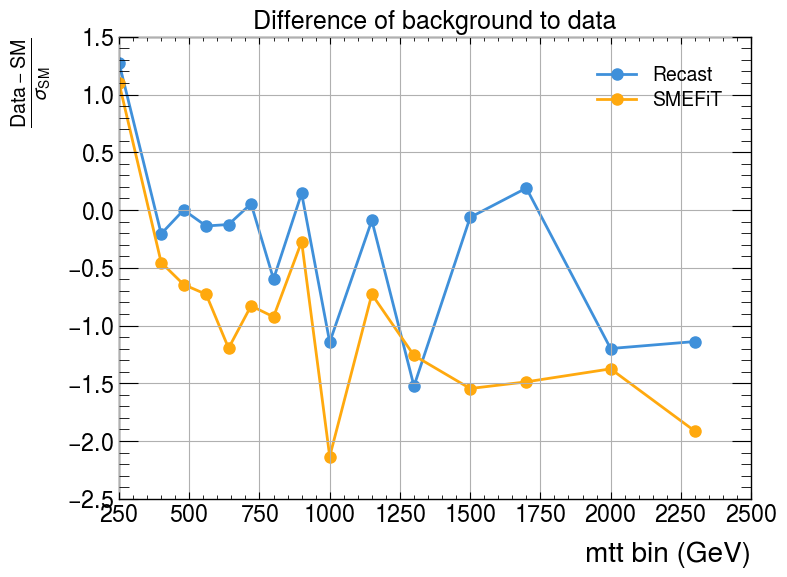

In [95]:

diff = ((xsecsObs)-sm/bin_widths)/(np.sqrt(np.diagonal(covMatrix_cms)))
diff_smefit = ((xsecsObs_smefit)-sm_NLO_smefit/bin_widths)/(np.sqrt(np.diagonal(covMatrix_smefit)))
plt.plot(cms_bins[:-1],diff,label='Recast',marker='o')
plt.plot(cms_bins[:-1],diff_smefit,marker='o',label='SMEFiT')
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{{\rm Data} - {\rm SM}}{\sigma_{\rm SM}}$')
plt.title('Difference of background to data',fontsize=18)
plt.legend()
plt.grid()
plt.show()

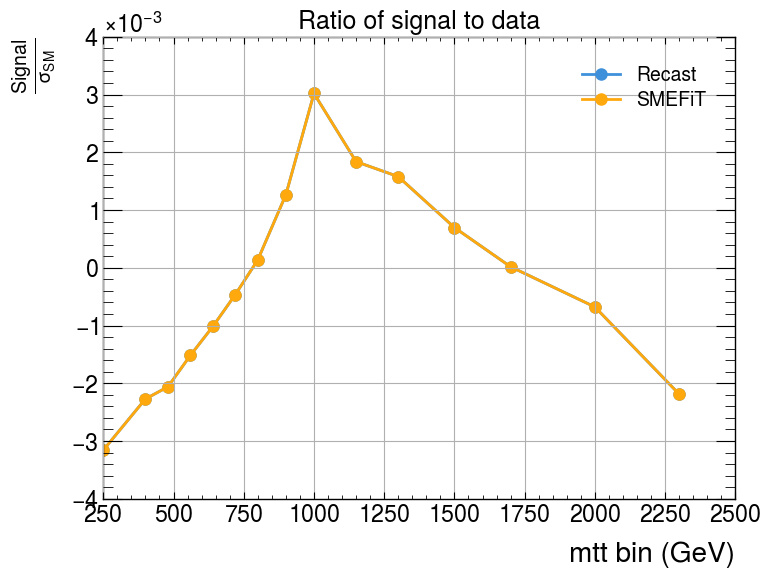

In [97]:

plt.plot(cms_bins[:-1],signal/(np.sqrt(np.diagonal(covMatrix_cms))*bin_widths),label='Recast',marker='o')
plt.plot(cms_bins[:-1],signal_smefit/(np.sqrt(np.diagonal(covMatrix_smefit))*bin_widths),marker='o',label='SMEFiT')
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{\rm Signal}{\sigma_{\rm SM}}$')
plt.title('Ratio of signal to data',fontsize=18)
plt.legend()
plt.grid()
plt.show()

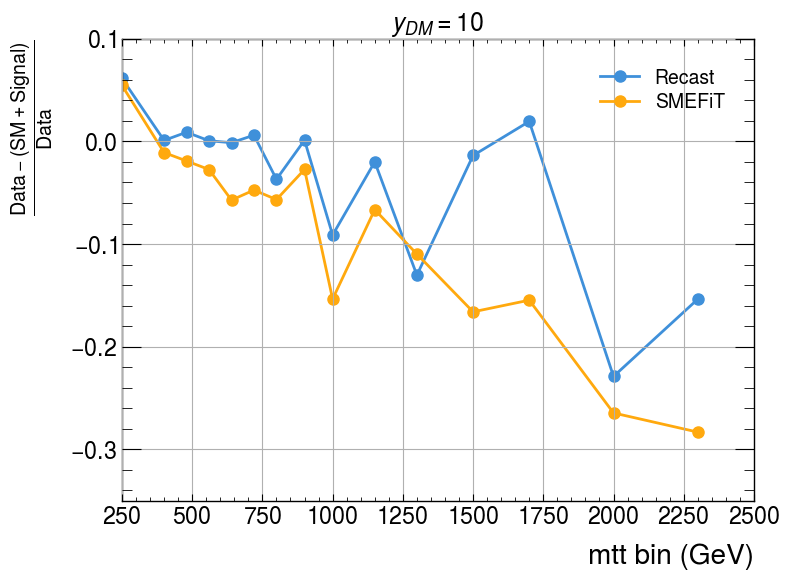

In [80]:
yDMx = 10
diff = ((xsecsObs*bin_widths)-(sm+yDMx**2*signal))/(xsecsObs*bin_widths)
diff_smefit = ((xsecsObs_smefit*bin_widths)-(sm_NLO_smefit+yDMx**2*signal_smefit))/(xsecsObs_smefit*bin_widths)


plt.plot(cms_bins[:-1],diff,label='Recast',marker='o')
plt.plot(cms_bins[:-1],diff_smefit,marker='o',label='SMEFiT')
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{{\rm Data} - ({\rm SM + Signal})}{\rm Data}$')
plt.title(r'$y_{DM} = %1.0f$' %yDMx,fontsize=18)
plt.legend()
plt.grid()
plt.show()

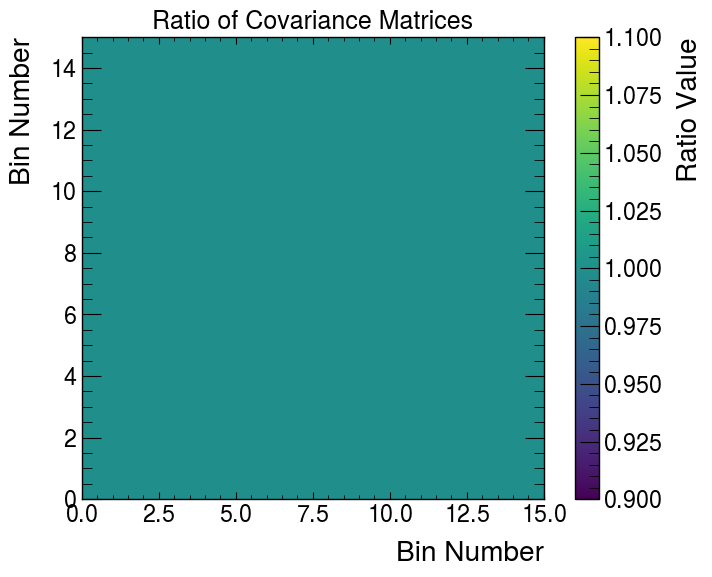

In [81]:
cov_ratio = covMatrix_smefit/covMatrix_cms
plt.figure(figsize=(8, 6))
plt.imshow(cov_ratio, cmap='viridis', origin='lower', extent=[0, cov_ratio.shape[1], 0, cov_ratio.shape[0]])
plt.colorbar(label='Ratio Value')
plt.title('Ratio of Covariance Matrices',fontsize=18)
plt.xlabel('Bin Number')
plt.ylabel('Bin Number')
plt.show()

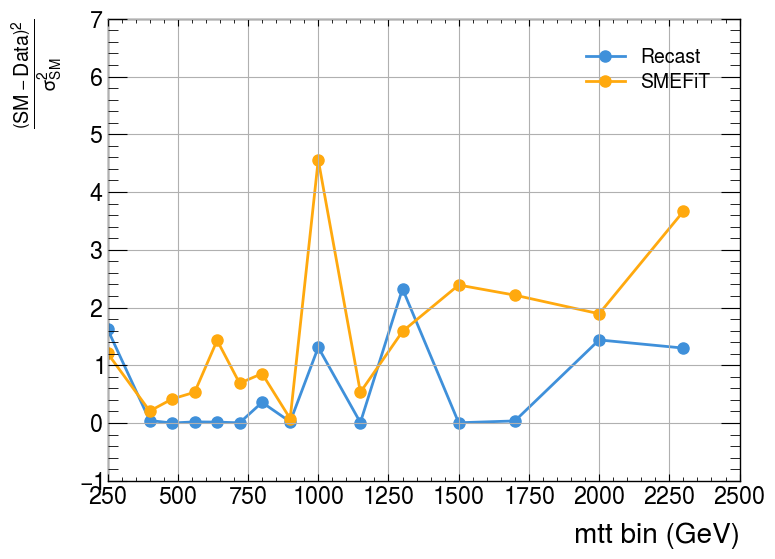

8.50025890763079 22.249338270772107


In [89]:
chi2_diag = (sm/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)
plt.plot(cms_bins[:-1],chi2_diag,marker='o',label='Recast')
chi2_diag_tot = np.sum(chi2_diag)

chi2_diag_smefit = (sm_NLO_smefit/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)
plt.plot(cms_bins[:-1],chi2_diag_smefit,marker='o',label='SMEFiT')
chi2_diag_tot_smefit = np.sum(chi2_diag_smefit)
plt.legend()
plt.grid()
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{\left({\rm SM} - {\rm Data}\right)^2}{\rm \sigma_{\rm SM}^2}$')
plt.ylim(-1,7)
plt.show()
print(chi2_diag_tot,chi2_diag_tot_smefit)

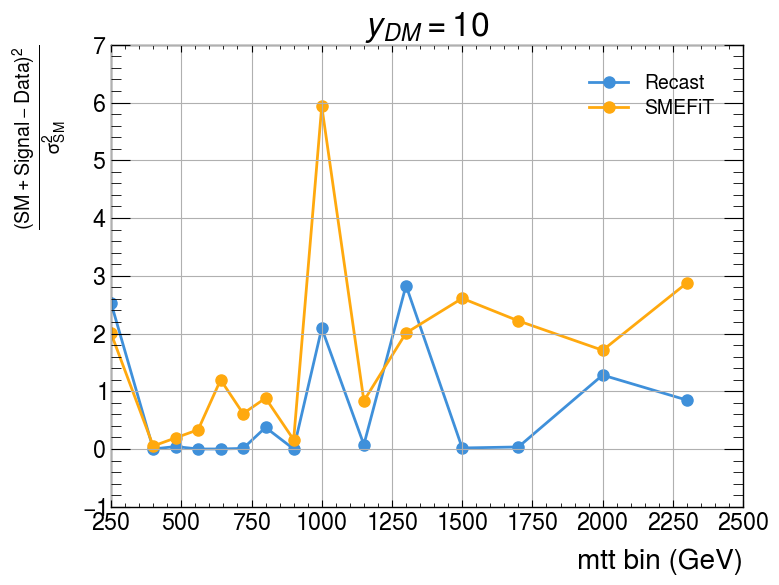

10.133311218875775 23.625833196558922


In [90]:
yDMx = 10.0
chi2_diag = ((sm+yDMx**2*signal)/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)
plt.plot(cms_bins[:-1],chi2_diag,marker='o',label='Recast')
chi2_diag_tot = np.sum(chi2_diag)

chi2_diag_smefit = ((sm_NLO_smefit+yDMx**2*signal)/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)
plt.plot(cms_bins[:-1],chi2_diag_smefit,marker='o',label='SMEFiT')
chi2_diag_tot_smefit = np.sum(chi2_diag_smefit)

plt.legend()
plt.grid()
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{\left({\rm SM} + {\rm Signal} - {\rm Data}\right)^2}{\rm \sigma_{\rm SM}^2}$')
plt.title(r'$y_{DM} = %1.0f$' %yDMx)
plt.ylim(-1,7)
plt.show()
print(chi2_diag_tot,chi2_diag_tot_smefit)

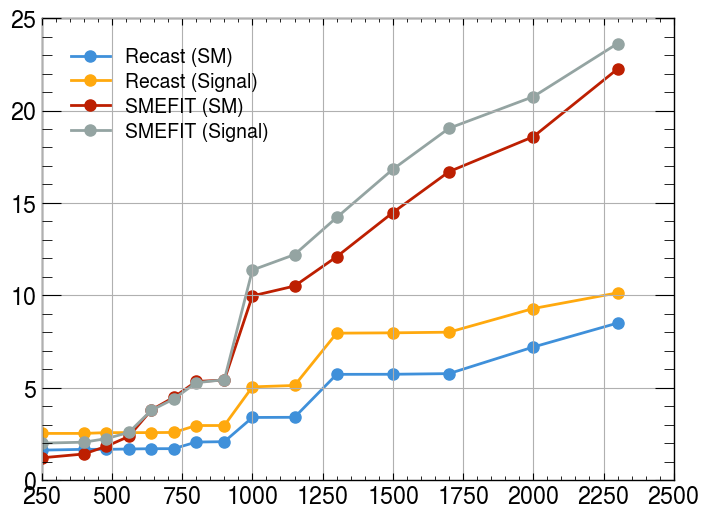

In [94]:
yDMx = 10.0

chi2_diag_sm = (sm/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)
chi2_diag_sig = ((sm+yDMx**2*signal)/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)

chi2_diag_sm_smefit = (sm_NLO_smefit/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)
chi2_diag_sig_smefit = ((sm_NLO_smefit+yDMx**2*signal)/bin_widths-xsecsObs)**2/np.diagonal(covMatrix_cms)

labels = ['Recast (SM)','Recast (Signal)','SMEFIT (SM)','SMEFIT (Signal)']
for y,label in zip([chi2_diag_sm,chi2_diag_sig,chi2_diag_sm_smefit,chi2_diag_sig_smefit],labels):
    yvals = [sum(y[:i]) for i in range(1,len(y)+1)]
    plt.plot(cms_bins[:-1],yvals,label=label,marker='o')
plt.grid()
plt.legend()
plt.show()


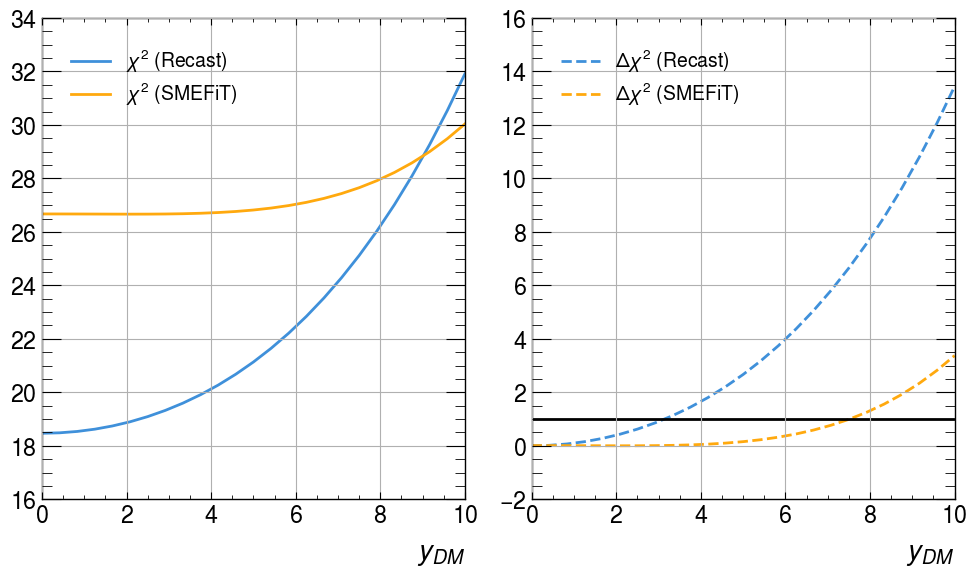

In [39]:
yDMvalues = np.linspace(0.,10.,25)
chi2_values = [chi2(yDM,signal/bin_widths,sm/bin_widths,xsecsObs,covMatrix_cms) for yDM in yDMvalues]
chi2_values_smefit = [chi2(yDM,signal/bin_widths,sm_NLO_smefit/bin_widths,xsecsObs,covMatrix_cms) for yDM in yDMvalues]

f = plt.figure(figsize=(10,6))
plt.subplot(1, 2, 1)
plt.plot(yDMvalues,chi2_values,label=r'$\chi^2$ (Recast)')
plt.plot(yDMvalues,chi2_values_smefit,label=r'$\chi^2$ (SMEFiT)')
plt.legend()
plt.grid()
plt.xlabel(r'$y_{DM}$')

plt.subplot(1, 2, 2)
plt.plot(yDMvalues,chi2_values-min(chi2_values),label=r'$\Delta \chi^2$ (Recast)',linestyle='dashed')
plt.plot(yDMvalues,chi2_values_smefit-min(chi2_values_smefit),label=r'$\Delta \chi^2$ (SMEFiT)',linestyle='dashed')
plt.hlines(y=1.0,xmin=min(yDMvalues),xmax=max(yDMvalues),linestyles='solid',colors='black')
plt.legend()
plt.grid()
plt.xlabel(r'$y_{DM}$')

plt.tight_layout()
plt.show()


The above behavior is due to the fact that for bins 2-6 the signal, which is negative, brings the SMEFiT background in closer agreement to data. For the higher bins the signal is positive and worsens the agreement. Hence there are partial cancellations in the contribution to $\chi^2$, making it grow slowly with the signal.
For the Recast background the agreement with data in the first bins is better and there are no cancellations, thus making $\chi^2$ grow faster with the signal.

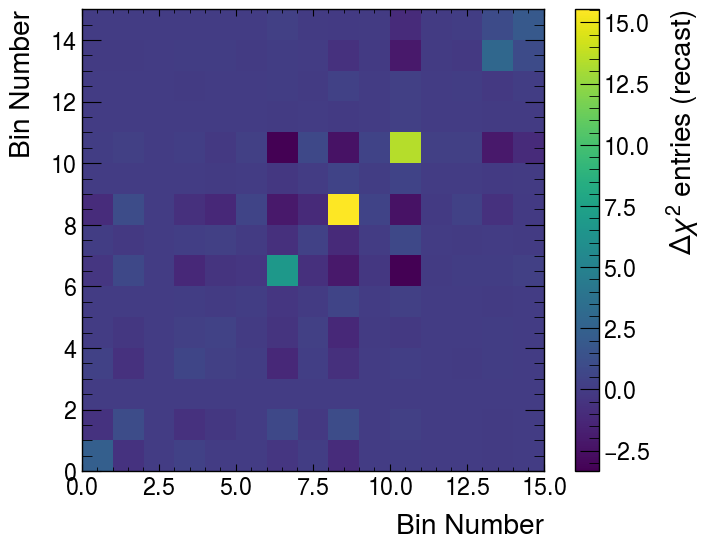

In [57]:
plt.figure(figsize=(8, 6))
plt.imshow(chi2_entries-0*min(chi2_values), cmap='viridis', origin='lower', extent=[0, chi2_entries.shape[1], 0, chi2_entries.shape[0]])
plt.colorbar(label=r'$\Delta \chi^2$ entries (recast)')
# plt.title('Ratio of Covariance Matrices',fontsize=18)
plt.xlabel('Bin Number')
plt.ylabel('Bin Number')
plt.show()

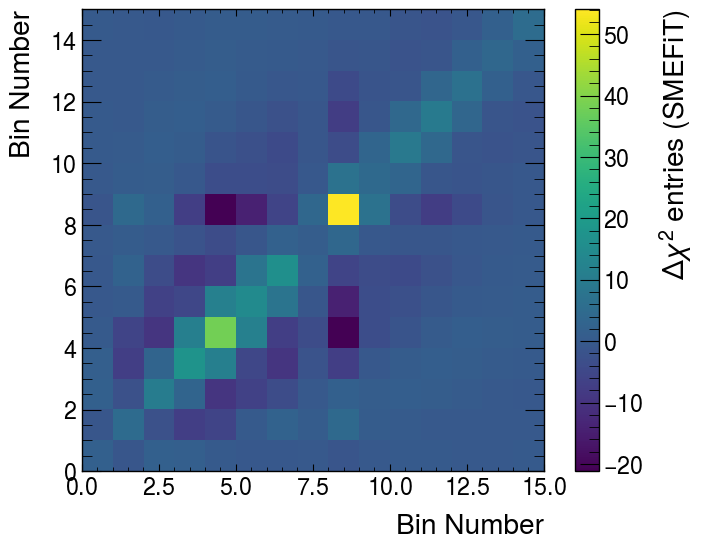

In [58]:
plt.figure(figsize=(8, 6))
plt.imshow(chi2_entries_smefit-0*min(chi2_values_smefit), cmap='viridis', origin='lower', extent=[0, chi2_entries_smefit.shape[1], 0, chi2_entries_smefit.shape[0]])
plt.colorbar(label=r'$\Delta \chi^2$ entries (SMEFiT)')
# plt.title('Ratio of Covariance Matrices',fontsize=18)
plt.xlabel('Bin Number')
plt.ylabel('Bin Number')
plt.show()